### Data Splitting, Feature Scaling & Class Imbalance

This notebook consists of the following: 
1. **Stratified train/test split**: preserves the minority-class ratio in both sets.
2. **Feature scaling**: StandardScaler fitted on train, applied to both train and test. Only continuous numerical features are scaled; binary and ordinal columns are left untouched.
3. **Class imbalance handling**: SMOTE applied **only** to the training set, producing a balanced synthetic dataset ready for classifiers.

**Outputs saved to `data/processed/splits/`:**
| File | Contents |
|---|---|
| `X_train_scaled.csv` | Scaled and SMOTE-resampled training features |
| `X_test_scaled.csv` | Scaled test features (no SMOTE) |
| `y_train_resampled.csv` | Resampled training labels |
| `y_test.csv` | Original test labels |
| `scaler.joblib` | Fitted StandardScaler (for inference) |

In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

PROJECT_ROOT  = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
SPLITS_DIR    = PROCESSED_DIR / "splits"
SPLITS_DIR.mkdir(parents=True, exist_ok=True)

FEATURED_PATH = PROCESSED_DIR / "telco_featured.csv"
print("Splits will be saved to:", SPLITS_DIR)

Splits will be saved to: C:\Users\Ahana\Desktop\telco-churn-ml-lab\data\processed\splits


In [3]:
df = pd.read_csv(FEATURED_PATH)

# pd.get_dummies creates boolean dtype in newer pandas and cast to int so all columns are numeric
bool_cols = df.select_dtypes(include="bool").columns.tolist()
if bool_cols:
    df[bool_cols] = df[bool_cols].astype(int)
    print(f"Cast {len(bool_cols)} boolean columns to int: {bool_cols}")

print(f"\nLoaded shape: {df.shape}")
print(f"Dtypes: {dict(df.dtypes.value_counts())}")
df.head(3)

Cast 7 boolean columns to int: ['internet_dsl', 'internet_fiber_optic', 'internet_no', 'payment_bank_transfer_automatic', 'payment_credit_card_automatic', 'payment_electronic_check', 'payment_mailed_check']

Loaded shape: (7032, 39)
Dtypes: {dtype('int64'): np.int64(33), dtype('float64'): np.int64(6)}


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,early_tenure,high_risk_combo,contract_encoded,internet_dsl,internet_fiber_optic,internet_no,payment_bank_transfer_automatic,payment_credit_card_automatic,payment_electronic_check,payment_mailed_check
0,0,0,1,0,1,0,0,0,1,0,...,1,1,0,1,0,0,0,0,1,0
1,1,0,0,0,34,1,0,1,0,1,...,0,0,1,1,0,0,0,0,0,1
2,1,0,0,0,2,1,0,1,1,0,...,1,1,0,1,0,0,0,0,0,1


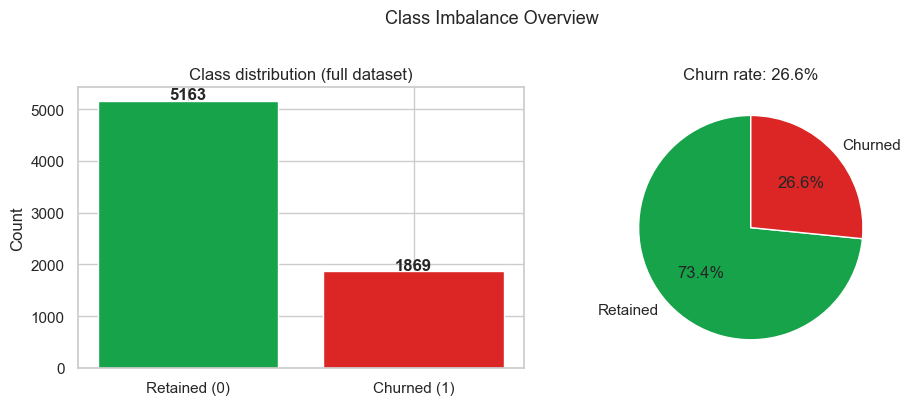

Class 0 (Retained): 5,163  (73.4%)
Class 1 (Churned):  1,869  (26.6%)
Imbalance ratio:    2.8:1


In [4]:
churn_counts = df["Churn"].value_counts()
churn_rate   = df["Churn"].mean()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart
axes[0].bar(["Retained (0)", "Churned (1)"], churn_counts.values,
            color=["#16a34a", "#dc2626"], edgecolor="white")
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 30, str(v), ha="center", fontweight="bold")
axes[0].set_title("Class distribution (full dataset)")
axes[0].set_ylabel("Count")

# Pie chart
axes[1].pie(churn_counts.values, labels=["Retained", "Churned"],
            colors=["#16a34a", "#dc2626"], autopct="%1.1f%%",
            startangle=90, wedgeprops={"edgecolor": "white"})
axes[1].set_title(f"Churn rate: {churn_rate:.1%}")

plt.suptitle("Class Imbalance Overview", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

print(f"Class 0 (Retained): {churn_counts[0]:,}  ({churn_counts[0]/len(df):.1%})")
print(f"Class 1 (Churned):  {churn_counts[1]:,}  ({churn_counts[1]/len(df):.1%})")
print(f"Imbalance ratio:    {churn_counts[0]/churn_counts[1]:.1f}:1")

### Defining Feature Groups

Scaling should only be applied to **continuous numerical features** that is features with a wide, real-valued range where magnitude differences are meaningful.

| Group | Columns | Scale? | Reason |
|---|---|---|---|
| Continuous numeric | tenure, MonthlyCharges, TotalCharges, avg_monthly_spend, charges_to_avg_ratio, log_monthly_charges, log_total_charges | **Yes** | Wide ranges; linear models sensitive to magnitude |
| Binary 0/1 | gender, SeniorCitizen, Partner, … | No | Already in [0, 1]; scaling would add noise |
| Ordinal 0-N | contract_encoded, tenure_group_encoded, num_add_on_services | No | Small integer range; order is meaningful |
| One-hot | internet_*, payment_* | No | Indicator variables; scaling breaks interpretation |

In [5]:
TARGET = "Churn"

# Continuous features that benefit from StandardScaler
CONTINUOUS_COLS = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "avg_monthly_spend",
    "charges_to_avg_ratio",
    "log_monthly_charges",
    "log_total_charges",
]

# All feature columns (everything except target)
FEATURE_COLS = [c for c in df.columns if c != TARGET]

# Discrete features (binary, ordinal, one-hot) — not scaled
DISCRETE_COLS = [c for c in FEATURE_COLS if c not in CONTINUOUS_COLS]

print(f"Total features : {len(FEATURE_COLS)}")
print(f"Continuous (scale) : {len(CONTINUOUS_COLS)}")
print(f"Discrete (no scale): {len(DISCRETE_COLS)}")
print("\nContinuous cols:", CONTINUOUS_COLS)
print("\nDiscrete cols:", DISCRETE_COLS)

Total features : 38
Continuous (scale) : 7
Discrete (no scale): 31

Continuous cols: ['tenure', 'MonthlyCharges', 'TotalCharges', 'avg_monthly_spend', 'charges_to_avg_ratio', 'log_monthly_charges', 'log_total_charges']

Discrete cols: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'tenure_group_encoded', 'num_add_on_services', 'has_protective_services', 'has_streaming', 'is_month_to_month', 'is_electronic_check', 'is_auto_payment', 'senior_alone', 'early_tenure', 'high_risk_combo', 'contract_encoded', 'internet_dsl', 'internet_fiber_optic', 'internet_no', 'payment_bank_transfer_automatic', 'payment_credit_card_automatic', 'payment_electronic_check', 'payment_mailed_check']


### Stratified Train / Test Split

 **Stratified splitting** (`stratify=y`) is done so that both the train and test sets preserve the original ~26% churn rate. Without stratification, a random split on an imbalanced dataset can accidentally put a disproportionate number of churners in one partition, making evaluation unreliable.

| Split | Size | Purpose |
|---|---|---|
| Train (80%) | ~5,625 rows | Fit scaler + classifier; SMOTE applied here |
| Test  (20%) | ~1,407 rows | Final evaluation; **never** touched by SMOTE or scaler fitting |

In [7]:
X = df[FEATURE_COLS]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,       # preserves churn ratio in both splits
)

print(f"Train size: {len(X_train):,}  ({len(X_train)/len(df):.0%} of dataset)")
print(f"Test  size: {len(X_test):,}  ({len(X_test)/len(df):.0%} of dataset)")

# Verify stratification worked
print(f"\nChurn rate - full dataset: {y.mean():.3f}")
print(f"Churn rate - train split:  {y_train.mean():.3f}")
print(f"Churn rate - test  split:  {y_test.mean():.3f}")

Train size: 5,625  (80% of dataset)
Test  size: 1,407  (20% of dataset)

Churn rate - full dataset: 0.266
Churn rate - train split:  0.266
Churn rate - test  split:  0.266


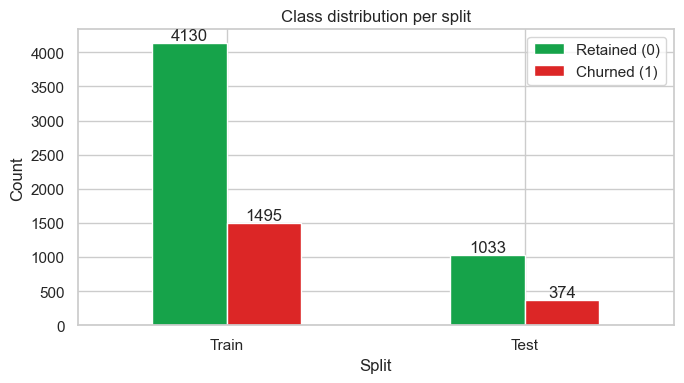

Split  Retained (0)  Churned (1)
Train          4130         1495
 Test          1033          374


In [8]:
split_df = pd.DataFrame({
    "Split": ["Train", "Test"],
    "Retained (0)": [
        (y_train == 0).sum(),
        (y_test == 0).sum(),
    ],
    "Churned (1)": [
        (y_train == 1).sum(),
        (y_test == 1).sum(),
    ],
})

ax = split_df.set_index("Split").plot(
    kind="bar", figsize=(7, 4),
    color=["#16a34a", "#dc2626"], edgecolor="white", rot=0
)
ax.set_title("Class distribution per split")
ax.set_ylabel("Count")
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.show()

print(split_df.to_string(index=False))

### Feature Scaling (Continuation of Feature Engineering)

#### Why StandardScaler?
`StandardScaler` transforms each feature to have **mean = 0, std = 1**. This is essential for:
- **Logistic Regression / SVM / KNN** as these are distance- or gradient-based; larger-magnitude features (e.g. `TotalCharges` ~ 0-8684) dominate smaller ones (e.g. `tenure` ~ 1-72) without scaling.
- **Regularisation (L1/L2)**:  penalty is applied in feature-space; unscaled features get unfairly penalised or let off.

Tree-based models (Random Forest, XGBoost) are **scale-invariant** as they split on thresholds, not magnitudes. Scaling doesn't hurt them but isn't necessary.

#### Key rule: fit on train, transform both
We **fit the scaler only on `X_train`**, then apply it to both `X_train` and `X_test`. Fitting on the full dataset would leak test-set statistics into training which is a form of data leakage that inflates validation scores.

In [9]:
scaler = StandardScaler()

# Fit ONLY on training data
scaler.fit(X_train[CONTINUOUS_COLS])

# Apply to both splits
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[CONTINUOUS_COLS] = scaler.transform(X_train[CONTINUOUS_COLS])
X_test_scaled[CONTINUOUS_COLS]  = scaler.transform(X_test[CONTINUOUS_COLS])

# Verify: scaled columns should have mean ≈ 0 and std ≈ 1 on train
print("Post-scaling statistics on TRAIN (continuous cols only):")
print(
    X_train_scaled[CONTINUOUS_COLS]
    .agg(["mean", "std"]).round(3).to_string()
)

# Save fitted scaler
scaler_path = SPLITS_DIR / "scaler.joblib"
joblib.dump(scaler, scaler_path)
print(f"\nScaler saved: {scaler_path}")

Post-scaling statistics on TRAIN (continuous cols only):
      tenure  MonthlyCharges  TotalCharges  avg_monthly_spend  charges_to_avg_ratio  log_monthly_charges  log_total_charges
mean    -0.0             0.0           0.0               -0.0                  -0.0                  0.0                0.0
std      1.0             1.0           1.0                1.0                   1.0                  1.0                1.0

Scaler saved: C:\Users\Ahana\Desktop\telco-churn-ml-lab\data\processed\splits\scaler.joblib


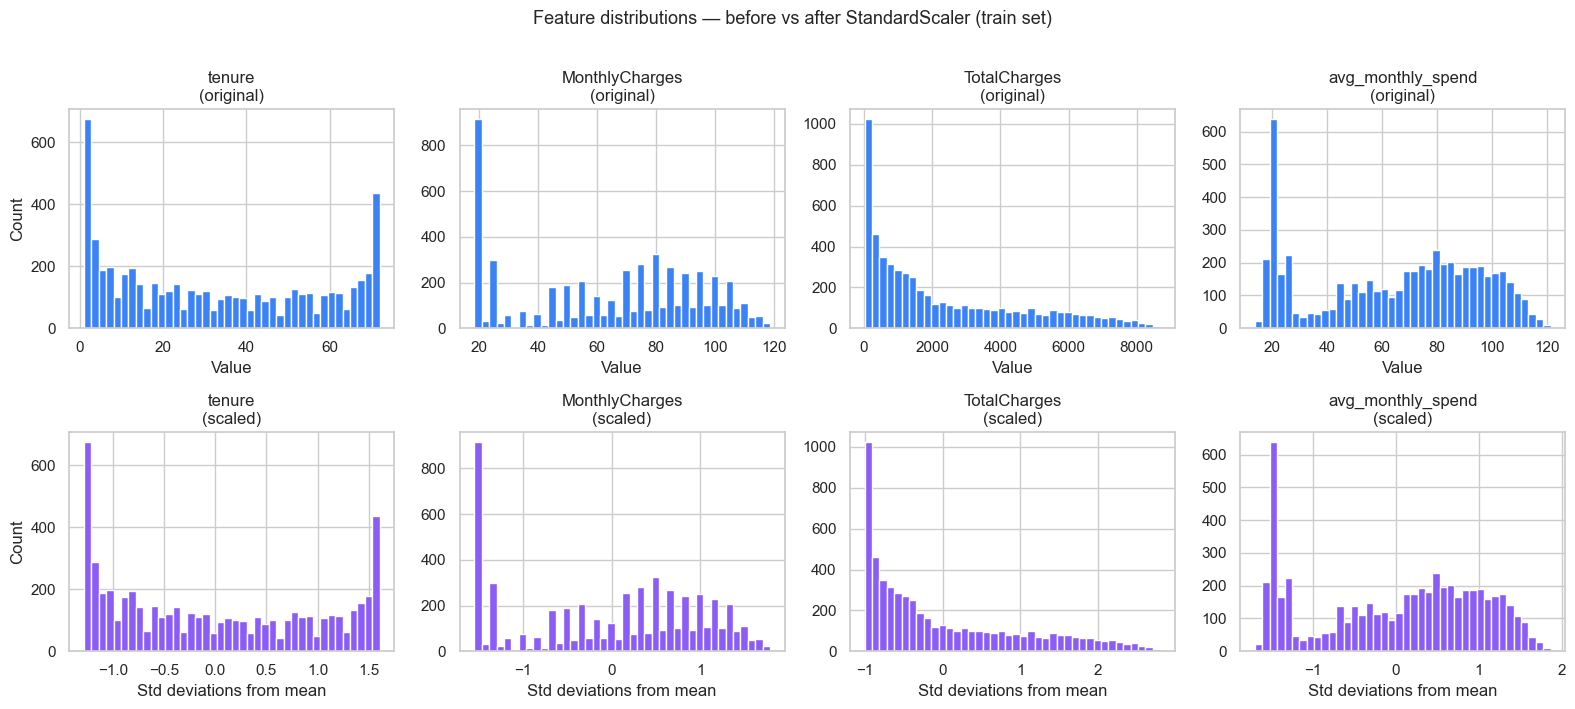

In [10]:
# Visual: before vs after scaling for 4 representative continuous columns
sample_cols = ["tenure", "MonthlyCharges", "TotalCharges", "avg_monthly_spend"]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))

for i, col in enumerate(sample_cols):
    # Before scaling
    axes[0, i].hist(X_train[col], bins=40, color="#3b82f6", edgecolor="white")
    axes[0, i].set_title(f"{col}\n(original)")
    axes[0, i].set_xlabel("Value")

    # After scaling
    axes[1, i].hist(X_train_scaled[col], bins=40, color="#8b5cf6", edgecolor="white")
    axes[1, i].set_title(f"{col}\n(scaled)")
    axes[1, i].set_xlabel("Std deviations from mean")

axes[0, 0].set_ylabel("Count")
axes[1, 0].set_ylabel("Count")

plt.suptitle("Feature distributions — before vs after StandardScaler (train set)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### Handling Class Imbalance with SMOTE

The dataset has a **~3.5:1 ratio** (retained vs churned). Training a classifier on this raw split will cause it to heavily favour predicting "Not Churned" and thus, achieving high accuracy but poor recall on the minority class (churners), which is exactly what we care about.

### Options

| Strategy | Mechanism | When to use |
|---|---|---|
| **SMOTE** (used here) | Synthetically interpolates new minority samples | Good baseline; works with most classifiers |
| **SMOTE-Tomek** (also shown) | SMOTE + removes borderline majority samples | Cleaner decision boundary; slightly fewer samples |
| Class weights | Penalise misclassification of minority class during training | No new data created; use when SMOTE is too slow |
| Random oversampling | Duplicate existing minority rows | Prone to overfitting |

### Critical rule: SMOTE only on training data
SMOTE generates **synthetic** samples. If applied before splitting, synthetic samples derived from test-set rows leak into training and inflating metrics. Always split first, then apply SMOTE to the training set only.

In [11]:
smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)

X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE (train):")
print(f"  Class 0: {(y_train == 0).sum():,}")
print(f"  Class 1: {(y_train == 1).sum():,}")
print(f"  Total:   {len(y_train):,}")

print("\nAfter SMOTE (train):")
print(f"  Class 0: {(y_train_res == 0).sum():,}")
print(f"  Class 1: {(y_train_res == 1).sum():,}")
print(f"  Total:   {len(y_train_res):,}")
print(f"  Synthetic samples added: {len(y_train_res) - len(y_train):,}")
print(f"  New churn rate: {y_train_res.mean():.1%}")

Before SMOTE (train):
  Class 0: 4,130
  Class 1: 1,495
  Total:   5,625

After SMOTE (train):
  Class 0: 4,130
  Class 1: 4,130
  Total:   8,260
  Synthetic samples added: 2,635
  New churn rate: 50.0%


In [12]:
smote_tomek = SMOTETomek(random_state=RANDOM_STATE)
X_train_st, y_train_st = smote_tomek.fit_resample(X_train_scaled, y_train)

print("After SMOTE-Tomek (train):")
print(f"  Class 0: {(y_train_st == 0).sum():,}")
print(f"  Class 1: {(y_train_st == 1).sum():,}")
print(f"  Total:   {len(y_train_st):,}")
print(f"  New churn rate: {y_train_st.mean():.1%}")

After SMOTE-Tomek (train):
  Class 0: 4,023
  Class 1: 4,023
  Total:   8,046
  New churn rate: 50.0%


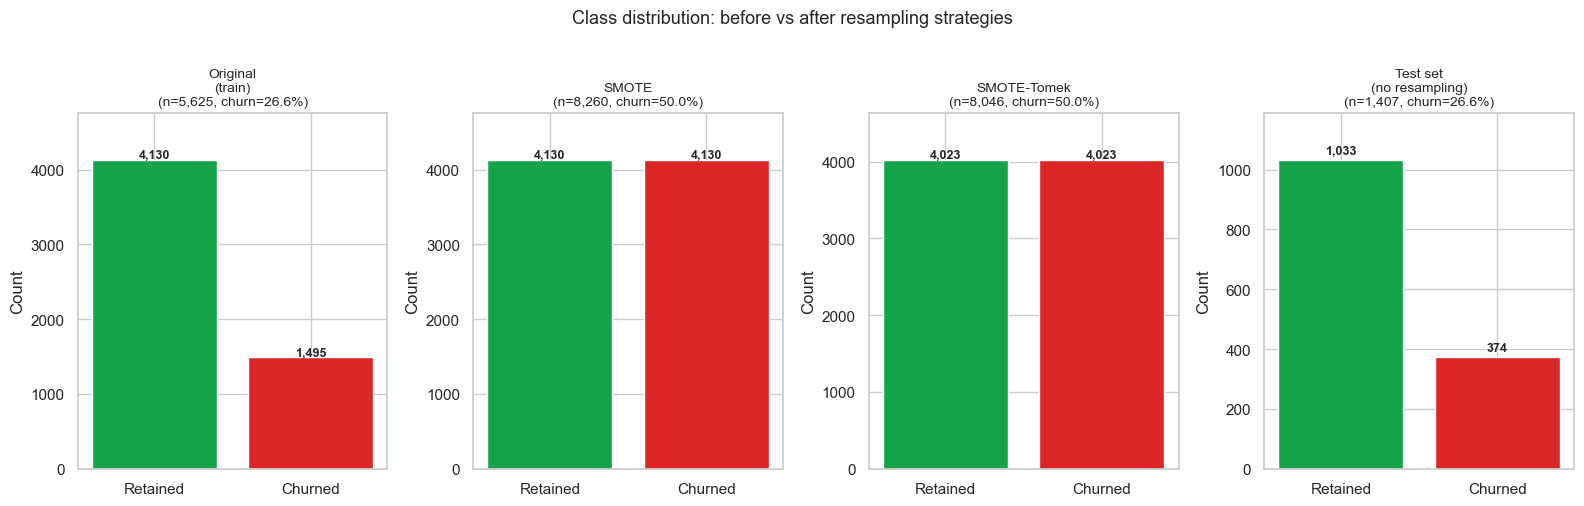

In [13]:
# Comparing class distributions across all versions
strategies = {
    "Original\n(train)": y_train,
    "SMOTE": y_train_res,
    "SMOTE-Tomek": y_train_st,
    "Test set\n(no resampling)": y_test,
}

fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for ax, (label, y_) in zip(axes, strategies.items()):
    counts = pd.Series(y_).value_counts().sort_index()
    ax.bar(["Retained", "Churned"], counts.values,
           color=["#16a34a", "#dc2626"], edgecolor="white")
    for i, v in enumerate(counts.values):
        ax.text(i, v + 20, f"{v:,}", ha="center", fontsize=9, fontweight="bold")
    ax.set_title(f"{label}\n(n={len(y_):,}, churn={y_.mean():.1%})", fontsize=10)
    ax.set_ylabel("Count")
    ax.set_ylim(0, max(counts.values) * 1.15)

plt.suptitle("Class distribution: before vs after resampling strategies",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

We save the **SMOTE** version as the default. 

| File | Rows | Description |
|---|---|---|
| `X_train_scaled.csv` | ~8,300 | SMOTE-resampled + scaled training features |
| `X_test_scaled.csv`  | ~1,407 | Scaled test features (never resampled) |
| `y_train_resampled.csv` | ~8,260 | Balanced training labels |
| `y_test.csv` | ~1,407 | Original test labels |
| `X_train_raw_scaled.csv` | ~5,625 | Scaled train features **without** SMOTE (for class-weight models) |
| `y_train_raw.csv` | ~5,625 | Original (imbalanced) training labels |
| `scaler.joblib` | — | Fitted StandardScaler |

In [14]:
# Convert resampled arrays back to DataFrames
X_train_res_df = pd.DataFrame(X_train_res, columns=X_train_scaled.columns)
y_train_res_s  = pd.Series(y_train_res, name=TARGET)

# Save all splits
save_map = {
    "X_train_scaled.csv"     : X_train_res_df,          # SMOTE + scaled (default for models)
    "X_test_scaled.csv"      : X_test_scaled,            # Scaled test (reset index for clean export)
    "y_train_resampled.csv"  : y_train_res_s,            # Balanced train labels
    "y_test.csv"             : y_test.reset_index(drop=True),
    "X_train_raw_scaled.csv" : X_train_scaled.reset_index(drop=True),  # Scaled, no SMOTE
    "y_train_raw.csv"        : y_train.reset_index(drop=True),          # Original labels
}

for filename, data in save_map.items():
    path = SPLITS_DIR / filename
    data.to_csv(path, index=False)
    print(f"Saved: {path.name}  shape={data.shape if hasattr(data, 'shape') else (len(data),)}")

print(f"\nScaler already saved to: {SPLITS_DIR / 'scaler.joblib'}")

Saved: X_train_scaled.csv  shape=(8260, 38)
Saved: X_test_scaled.csv  shape=(1407, 38)
Saved: y_train_resampled.csv  shape=(8260,)
Saved: y_test.csv  shape=(1407,)
Saved: X_train_raw_scaled.csv  shape=(5625, 38)
Saved: y_train_raw.csv  shape=(5625,)

Scaler already saved to: C:\Users\Ahana\Desktop\telco-churn-ml-lab\data\processed\splits\scaler.joblib


In [15]:
# Quick verification: reload and check shapes + churn rate
X_tr = pd.read_csv(SPLITS_DIR / "X_train_scaled.csv")
X_te = pd.read_csv(SPLITS_DIR / "X_test_scaled.csv")
y_tr = pd.read_csv(SPLITS_DIR / "y_train_resampled.csv").squeeze()
y_te = pd.read_csv(SPLITS_DIR / "y_test.csv").squeeze()
sc   = joblib.load(SPLITS_DIR / "scaler.joblib")

print("Reloaded files:")
print(f"  X_train_scaled : {X_tr.shape}")
print(f"  X_test_scaled  : {X_te.shape}")
print(f"  y_train_resampled churn rate: {y_tr.mean():.1%}")
print(f"  y_test churn rate:            {y_te.mean():.1%}  (original distribution preserved)")
print(f"  Scaler type: {type(sc).__name__}")
print(f"  Scaler features: {sc.feature_names_in_.tolist()}")

Reloaded files:
  X_train_scaled : (8260, 38)
  X_test_scaled  : (1407, 38)
  y_train_resampled churn rate: 50.0%
  y_test churn rate:            26.6%  (original distribution preserved)
  Scaler type: StandardScaler
  Scaler features: ['tenure', 'MonthlyCharges', 'TotalCharges', 'avg_monthly_spend', 'charges_to_avg_ratio', 'log_monthly_charges', 'log_total_charges']


### Summary

| Step | Choice | Reasoning |
|---|---|---|
| Split ratio | 80/20 | Standard; enough test data to estimate generalisation reliably |
| Stratification | `stratify=y` | Preserves ~26% churn rate in both sets |
| Scaler | `StandardScaler` | Mean=0 std=1 normalisation; fitted on train only |
| Scaled columns | 7 continuous features | Binary/ordinal/one-hot left unchanged |
| Resampling | SMOTE on train only | Creates synthetic minority samples; test set untouched |

### Output files

| File | Use |
|---|---|
| `X_train_scaled.csv` + `y_train_resampled.csv` | Default input for classifiers (balanced) |
| `X_test_scaled.csv` + `y_test.csv` | Evaluation on held-out, real-world distribution |
| `X_train_raw_scaled.csv` + `y_train_raw.csv` | For models that accept `class_weight="balanced"` |
| `scaler.joblib` | Apply to new data at inference time |

